# CMPE 255 Assignment 1 — Part 2
## Experiment 3: Association Pattern Mining

### AI-Assisted Replication of Instructor Data Science Experiment

This notebook replicates and adapts the association pattern mining experiment from the instructor's `data_science_examples` repository.

Association rule mining is commonly used to discover products or events that frequently occur together.

A classic application is **market basket analysis**, where transaction data is analyzed to identify combinations of items that customers often purchase together.

### Objectives

- Create and inspect transaction data
- Transform transactions into basket format
- Apply the Apriori algorithm
- Discover frequent itemsets
- Generate association rules
- Evaluate rules using support, confidence, and lift
- Interpret useful patterns
- Discuss possible business applications

### Adaptation

For this assignment, the experiment is implemented as a reproducible notebook using synthetic retail transactions. This keeps the workflow transparent while demonstrating the core methodology of association pattern mining.

In [8]:
!pip install mlxtend -q

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Business Understanding

Retail businesses often want to understand which products customers tend to purchase together.

Association pattern mining can support:

- Product recommendations
- Cross-selling
- Store layout decisions
- Promotional bundles
- Personalized marketing
- Inventory planning

Unlike classification or regression, association rule mining does not predict a single target variable.

Instead, it searches transaction data for frequent combinations of items and relationships between those items.

## 2. Transaction Data

A synthetic retail transaction dataset is used for this experiment.

The transactions contain common grocery items. Several purchasing patterns are intentionally embedded in the simulated data so that the association mining workflow can be evaluated.

The hidden purchasing patterns are not provided to the Apriori algorithm. The algorithm must discover frequent item combinations directly from the transactions.

In [10]:
# Create reproducible synthetic retail transactions

np.random.seed(42)

items = [
    "Bread",
    "Milk",
    "Eggs",
    "Cheese",
    "Coffee",
    "Cookies",
    "Pasta",
    "Tomato Sauce",
    "Chips",
    "Soda",
    "Apples",
    "Bananas"
]

transactions = []

for i in range(1000):

    basket = []

    # Common independent items
    for item in items:
        if np.random.rand() < 0.08:
            basket.append(item)

    # Embedded pattern 1: Bread and Milk
    if np.random.rand() < 0.30:
        basket.extend(["Bread", "Milk"])

    # Embedded pattern 2: Pasta and Tomato Sauce
    if np.random.rand() < 0.22:
        basket.extend(["Pasta", "Tomato Sauce"])

    # Embedded pattern 3: Chips and Soda
    if np.random.rand() < 0.20:
        basket.extend(["Chips", "Soda"])

    # Embedded pattern 4: Coffee and Cookies
    if np.random.rand() < 0.18:
        basket.extend(["Coffee", "Cookies"])

    # Add some realistic companion purchases
    if "Bread" in basket and np.random.rand() < 0.25:
        basket.append("Eggs")

    if "Coffee" in basket and np.random.rand() < 0.20:
        basket.append("Milk")

    # Remove duplicates
    basket = list(set(basket))

    # Make sure transaction is not empty
    if len(basket) == 0:
        basket.append(
            np.random.choice(items)
        )

    transactions.append(basket)

print("Number of transactions:", len(transactions))

print("\nFirst 10 transactions:")

for i in range(10):
    print(i + 1, transactions[i])

Number of transactions: 1000

First 10 transactions:
1 ['Pasta', 'Chips', 'Apples', 'Soda', 'Tomato Sauce']
2 ['Pasta', 'Milk', 'Coffee', 'Tomato Sauce', 'Cookies']
3 ['Soda']
4 ['Bread', 'Milk', 'Soda']
5 ['Pasta', 'Bananas', 'Eggs', 'Tomato Sauce']
6 ['Milk']
7 ['Pasta', 'Bananas', 'Bread', 'Milk', 'Eggs', 'Tomato Sauce']
8 ['Pasta', 'Tomato Sauce']
9 ['Chips', 'Soda']
10 ['Milk']


In [11]:
transaction_lengths = [
    len(transaction)
    for transaction in transactions
]

print("Transaction Statistics")
print("----------------------")

print(
    "Average number of items:",
    round(np.mean(transaction_lengths), 2)
)

print(
    "Median number of items:",
    np.median(transaction_lengths)
)

print(
    "Minimum number of items:",
    np.min(transaction_lengths)
)

print(
    "Maximum number of items:",
    np.max(transaction_lengths)
)

Transaction Statistics
----------------------
Average number of items: 2.91
Median number of items: 3.0
Minimum number of items: 1
Maximum number of items: 9


In [12]:
item_counts = {}

for transaction in transactions:

    for item in transaction:

        if item not in item_counts:
            item_counts[item] = 0

        item_counts[item] += 1


item_frequency = (
    pd.DataFrame(
        list(item_counts.items()),
        columns=[
            "Item",
            "Transaction_Count"
        ]
    )
    .sort_values(
        "Transaction_Count",
        ascending=False
    )
)

item_frequency

,Item,Transaction_Count
5,Milk,401
8,Bread,365
4,Tomato Sauce,306
0,Pasta,300
3,Soda,291
1,Chips,275
7,Cookies,264
6,Coffee,257
10,Eggs,191
2,Apples,92


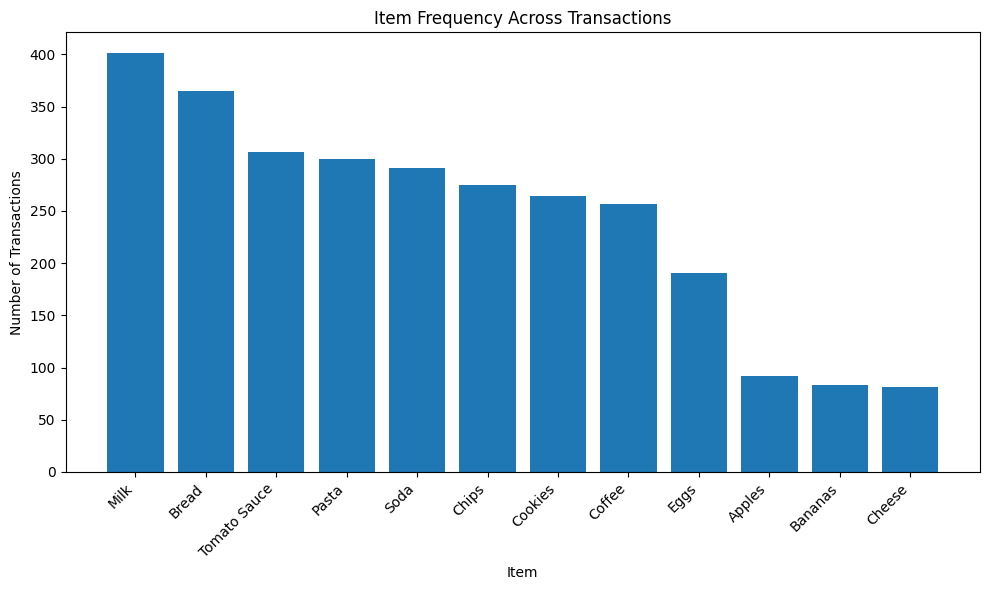

In [13]:
plt.figure(figsize=(10, 6))

plt.bar(
    item_frequency["Item"],
    item_frequency["Transaction_Count"]
)

plt.title("Item Frequency Across Transactions")
plt.xlabel("Item")
plt.ylabel("Number of Transactions")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

## 3. Data Preparation

Association rule algorithms require transactions to be represented as a binary basket matrix.

Each row represents one transaction and each column represents one product.

A value of `True` indicates that the product appeared in the transaction, while `False` indicates that it did not.

`TransactionEncoder` is used to perform this transformation.

In [14]:
encoder = TransactionEncoder()

encoded_array = encoder.fit(
    transactions
).transform(
    transactions
)

basket_df = pd.DataFrame(
    encoded_array,
    columns=encoder.columns_
)

print(
    "Basket matrix shape:",
    basket_df.shape
)

basket_df.head()

Basket matrix shape: (1000, 12)


,Apples,Bananas,Bread,Cheese,Chips,Coffee,Cookies,Eggs,Milk,Pasta,Soda,Tomato Sauce
0,True,False,False,False,True,False,False,False,False,True,True,True
1,False,False,False,False,False,True,True,False,True,True,False,True
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,True,False,False,False,False,False,True,False,True,False
4,False,True,False,False,False,False,False,True,False,True,False,True


## 4. Frequent Itemset Mining with Apriori

The Apriori algorithm identifies combinations of products that occur frequently across transactions.

The primary measure used at this stage is **support**.

Support represents the proportion of all transactions that contain a particular item or itemset.

For this experiment, a minimum support threshold of 0.10 is used. Therefore, an itemset must appear in at least 10% of transactions to be considered frequent.

In [15]:
frequent_itemsets = apriori(
    basket_df,
    min_support=0.10,
    use_colnames=True
)

frequent_itemsets["item_count"] = (
    frequent_itemsets["itemsets"]
    .apply(len)
)

frequent_itemsets = (
    frequent_itemsets
    .sort_values(
        "support",
        ascending=False
    )
)

print(
    "Number of frequent itemsets:",
    len(frequent_itemsets)
)

frequent_itemsets.head(20)

Number of frequent itemsets: 22


,support,itemsets,item_count
5,0.401,(Milk),1
0,0.365,(Bread),1
10,0.307,"(Bread, Milk)",2
8,0.306,(Tomato Sauce),1
6,0.300,(Pasta),1
7,0.291,(Soda),1
1,0.275,(Chips),1
3,0.264,(Cookies),1
2,0.257,(Coffee),1
20,0.238,"(Pasta, Tomato Sauce)",2


In [16]:
multi_itemsets = frequent_itemsets[
    frequent_itemsets["item_count"] >= 2
].copy()

multi_itemsets.head(15)

,support,itemsets,item_count
10,0.307,"(Bread, Milk)",2
20,0.238,"(Pasta, Tomato Sauce)",2
13,0.220,"(Chips, Soda)",2
14,0.192,"(Cookies, Coffee)",2
16,0.121,"(Milk, Cookies)",2
15,0.120,"(Milk, Coffee)",2
9,0.119,"(Bread, Eggs)",2
19,0.117,"(Milk, Tomato Sauce)",2
18,0.114,"(Milk, Pasta)",2
12,0.108,"(Bread, Tomato Sauce)",2


## 5. Association Rule Generation

Frequent itemsets can be converted into association rules.

Three important metrics are used:

### Support

How frequently the item combination appears in all transactions.

### Confidence

How often the consequent appears when the antecedent is present.

For example:

`Bread → Milk`

asks:

> Among transactions containing Bread, how often do they also contain Milk?

### Lift

Lift compares the observed co-occurrence with what would be expected if the items were independent.

- Lift greater than 1 indicates a positive association.
- Lift close to 1 suggests little association.
- Lift below 1 suggests a negative association.

Higher lift can indicate a more interesting relationship, but rules should be interpreted together with support and confidence.

In [17]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules = rules.sort_values(
    by="lift",
    ascending=False
)

print(
    "Number of association rules:",
    len(rules)
)

rules.head(20)

Number of association rules: 22


,antecedents,consequents,support,confidence,lift
7,(Coffee),(Cookies),0.192,0.747082,2.829855
6,(Cookies),(Coffee),0.192,0.727273,2.829855
4,(Chips),(Soda),0.220,0.800000,2.749141
5,(Soda),(Chips),0.220,0.756014,2.749141
3,(Tomato Sauce),(Pasta),0.238,0.777778,2.592593
2,(Pasta),(Tomato Sauce),0.238,0.793333,2.592593
20,"(Milk, Eggs)",(Bread),0.100,0.934579,2.560492
1,(Milk),(Bread),0.307,0.765586,2.097496
0,(Bread),(Milk),0.307,0.841096,2.097496
19,"(Bread, Eggs)",(Milk),0.100,0.840336,2.095601


In [18]:
rules_display = rules.copy()

rules_display["antecedents"] = (
    rules_display["antecedents"]
    .apply(
        lambda x: ", ".join(
            sorted(list(x))
        )
    )
)

rules_display["consequents"] = (
    rules_display["consequents"]
    .apply(
        lambda x: ", ".join(
            sorted(list(x))
        )
    )
)

rules_display.head(15).round(3)

,antecedents,consequents,support,confidence,lift
7,Coffee,Cookies,0.192,0.747,2.830
6,Cookies,Coffee,0.192,0.727,2.830
4,Chips,Soda,0.220,0.800,2.749
5,Soda,Chips,0.220,0.756,2.749
3,Tomato Sauce,Pasta,0.238,0.778,2.593
2,Pasta,Tomato Sauce,0.238,0.793,2.593
20,"Eggs, Milk",Bread,0.100,0.935,2.560
1,Milk,Bread,0.307,0.766,2.097
0,Bread,Milk,0.307,0.841,2.097
19,"Bread, Eggs",Milk,0.100,0.840,2.096


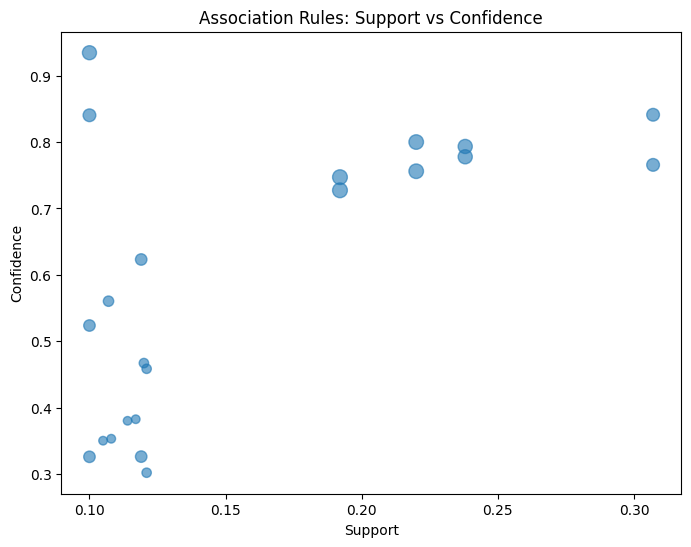

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rules["support"],
    rules["confidence"],
    s=rules["lift"] * 40,
    alpha=0.6
)

plt.title("Association Rules: Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")

plt.show()

## 6. Association Rule Interpretation

The Apriori analysis successfully identified several strong purchasing relationships.

### Coffee → Cookies

- Support: 0.192
- Confidence: 0.747
- Lift: 2.830

Approximately 19.2% of all transactions contain both Coffee and Cookies.

Among transactions containing Coffee, approximately 74.7% also contain Cookies.

The lift of 2.83 indicates that Coffee and Cookies occur together substantially more often than would be expected if their purchases were independent.

### Chips → Soda

- Support: 0.220
- Confidence: 0.800
- Lift: 2.749

Among transactions containing Chips, approximately 80.0% also contain Soda.

This represents another strong positive association.

### Pasta → Tomato Sauce

- Support: 0.238
- Confidence: 0.793
- Lift: 2.593

Approximately 79.3% of transactions containing Pasta also contain Tomato Sauce.

This combination also has relatively high support, indicating that it occurs frequently across the transaction dataset.

### Bread → Milk

- Support: 0.307
- Confidence: 0.841
- Lift: 2.097

Bread and Milk form the most frequently observed multi-item combination among the major discovered patterns.

Approximately 30.7% of all transactions contain both items, and approximately 84.1% of transactions containing Bread also contain Milk.

Overall, the discovered rules demonstrate that support, confidence, and lift provide complementary information about purchasing patterns.

## 7. Business Applications and Recommendations

The discovered association rules could support several retail strategies.

### Product Bundling

Strongly associated products could be offered together as promotional bundles.

Examples include:

- Coffee and Cookies
- Chips and Soda
- Pasta and Tomato Sauce
- Bread and Milk

### Cross-Selling Recommendations

When a customer adds one product to a shopping cart, the associated product could be recommended.

For example, a customer purchasing Pasta could receive a recommendation for Tomato Sauce.

### Store Layout

Frequently associated products could be positioned strategically within a physical store.

Depending on the business objective, related products could either be placed near each other for convenience or separated to encourage customers to move through additional store areas.

### Personalized Promotions

Association rules could support targeted coupons or promotions based on products already purchased by a customer.

### Inventory Planning

Products with strong associations may experience related demand patterns. Retailers could consider these relationships when planning inventory, while recognizing that association rules alone do not provide a complete demand forecast.

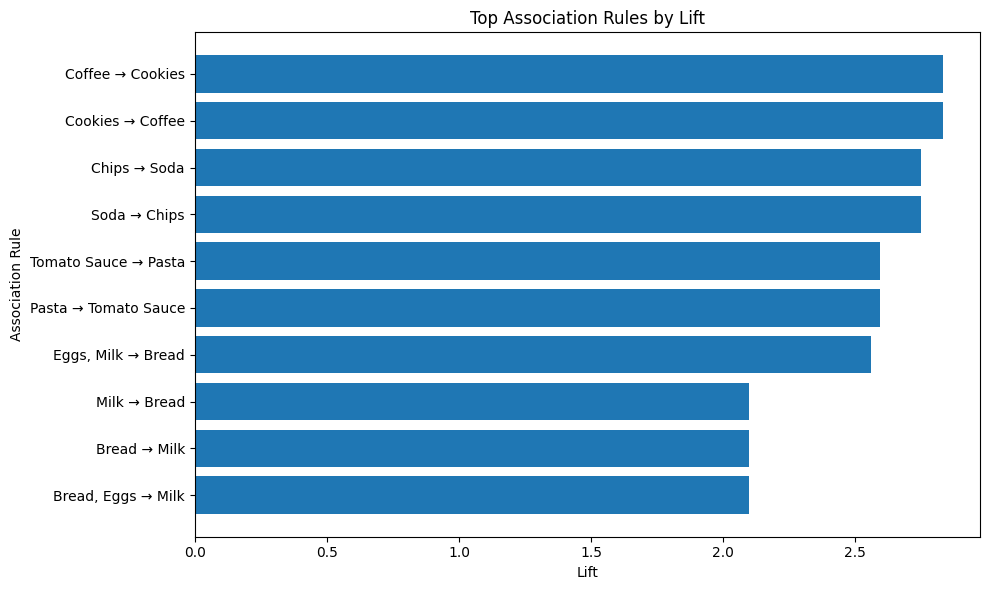

In [20]:
# Select the strongest rules by lift

top_rules = (
    rules_display
    .sort_values(
        "lift",
        ascending=False
    )
    .head(10)
    .copy()
)

top_rules["rule"] = (
    top_rules["antecedents"]
    + " → "
    + top_rules["consequents"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rules["rule"],
    top_rules["lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top Association Rules by Lift")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## 8. Limitations

This experiment uses synthetic transaction data with intentionally embedded purchasing patterns.

Therefore, the discovered rules should not be interpreted as evidence about real consumer behavior.

The experiment is designed to demonstrate the methodology of association pattern mining in a controlled and reproducible environment.

In a real retail application, the same workflow could be applied to actual transaction records containing thousands or millions of shopping baskets.

Additional considerations would include:

- Selecting appropriate support and confidence thresholds
- Filtering redundant association rules
- Evaluating rules across different customer groups
- Testing whether discovered patterns remain stable over time
- Considering business profitability before deploying recommendations

Association also does not imply causation. A rule such as `Coffee → Cookies` indicates that the products frequently occur together in this dataset, but it does not demonstrate that purchasing Coffee causes a customer to purchase Cookies.

## 9. Experiment Conclusion

This experiment replicated and adapted the instructor's association pattern mining project using a market basket analysis workflow.

The analysis included:

- Transaction data generation and exploration
- Basket encoding
- Frequent itemset mining with Apriori
- Association rule generation
- Support, confidence, and lift analysis
- Rule visualization
- Business interpretation
- Limitations and deployment considerations

The strongest discovered relationships included:

- **Coffee → Cookies:** Lift = 2.830
- **Chips → Soda:** Lift = 2.749
- **Pasta → Tomato Sauce:** Lift = 2.593
- **Bread → Milk:** Lift = 2.097

The Bread and Milk combination appeared in approximately **30.7%** of all transactions, while the Coffee and Cookies relationship achieved the highest lift among the major two-item rules.

These results demonstrate how association pattern mining can transform transaction data into interpretable relationships that could support product recommendations, cross-selling, promotions, and other retail decisions.